In [1]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from ipynb.fs.defs.competition1 import create_sparse_matrix, compute_stats

In [2]:
file = "data/train.csv"
df = pd.read_csv(file, header=0)
df.head()

,user,item,rating
0,1,25715,7.0
1,1,25716,10.0
2,5,25851,9.0
3,6,25923,5.0
4,7,25924,6.0


In [3]:
y = df["rating"]
x = df.drop(columns="rating")
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=42, stratify=df.rating)

In [11]:
class PMF:
    def __init__(self, n_factors=10, lambda_U=0.01, lambda_V=0.01,
                 lr=0.001, n_epochs=100, batch_size=1024,
                 clip_min=1.0, clip_max=10.0, random_state=42,
                 optimizer='adam'):
        self.n_factors    = n_factors
        self.lambda_U     = lambda_U
        self.lambda_V     = lambda_V
        self.lr           = lr
        self.n_epochs     = n_epochs
        self.batch_size   = batch_size
        self.clip_min     = clip_min
        self.clip_max     = clip_max
        self.random_state = random_state
        self.optimizer    = optimizer   # 'sgd' | 'adam'

        self.U = None
        self.V = None
        self.train_rmse = []
        self.val_rmse   = []

    def _init_factors(self, n_users, n_items):
        rng   = np.random.default_rng(self.random_state)
        scale = 1 / np.sqrt(self.n_factors)
        self.U = rng.normal(0, scale, (n_users, self.n_factors))
        self.V = rng.normal(0, scale, (n_items, self.n_factors))

        if self.optimizer == 'adam':
            self.mU = np.zeros_like(self.U); self.vU = np.zeros_like(self.U)
            self.mV = np.zeros_like(self.V); self.vV = np.zeros_like(self.V)
            self._adam_t = 0

    def _adam_update(self, param, m, v, grad, beta1=0.9, beta2=0.999, eps=1e-8):
        self._adam_t += 1
        m[:] = beta1 * m + (1 - beta1) * grad
        v[:] = beta2 * v + (1 - beta2) * grad ** 2
        m_hat = m / (1 - beta1 ** self._adam_t)
        v_hat = v / (1 - beta2 ** self._adam_t)
        param -= self.lr * m_hat / (np.sqrt(v_hat) + eps)

    def _compute_rmse(self, user_idx, item_idx, ratings):
        """RMSE puro, sin regularización — para monitorizar de forma legible."""
        preds  = np.clip(
            np.sum(self.U[user_idx] * self.V[item_idx], axis=1),
            self.clip_min, self.clip_max
        )
        return np.sqrt(np.mean((ratings - preds) ** 2))

    def fit(self, x_train, y_train, x_val, y_val,
            user_map, item_map, patience=10):

        train_users = x_train['user'].map(user_map).values
        train_items = x_train['item'].map(item_map).values
        train_r     = y_train.values.astype(np.float64)

        val_mask  = x_val['user'].isin(user_map) & x_val['item'].isin(item_map)
        val_users = x_val.loc[val_mask, 'user'].map(user_map).values
        val_items = x_val.loc[val_mask, 'item'].map(item_map).values
        val_r     = y_val[val_mask].values.astype(np.float64)

        n_users, n_items = len(user_map), len(item_map)
        self._init_factors(n_users, n_items)

        n_samples  = len(train_r)
        rng        = np.random.default_rng(self.random_state)
        best_val   = np.inf
        best_U, best_V = self.U.copy(), self.V.copy()
        no_improve = 0

        for epoch in tqdm(range(self.n_epochs), desc='Training PMF'):
            perm   = rng.permutation(n_samples)
            u_shuf = train_users[perm]
            i_shuf = train_items[perm]
            r_shuf = train_r[perm]

            for start in range(0, n_samples, self.batch_size):
                end = min(start + self.batch_size, n_samples)
                u_b = u_shuf[start:end]
                i_b = i_shuf[start:end]
                r_b = r_shuf[start:end]

                U_b    = self.U[u_b]
                V_b    = self.V[i_b]
                errors = r_b - np.sum(U_b * V_b, axis=1)  # (batch,)

                # Gradientes con regularización solo sobre el batch
                grad_U = -2 * errors[:, None] * V_b + 2 * self.lambda_U * U_b
                grad_V = -2 * errors[:, None] * U_b + 2 * self.lambda_V * V_b

                if self.optimizer == 'adam':
                    # Adam necesita índices únicos para actualizar correctamente
                    for idx_u in np.unique(u_b):
                        mask = u_b == idx_u
                        g    = grad_U[mask].mean(axis=0)
                        self._adam_update(
                            self.U[idx_u], self.mU[idx_u], self.vU[idx_u], g
                        )
                    for idx_i in np.unique(i_b):
                        mask = i_b == idx_i
                        g    = grad_V[mask].mean(axis=0)
                        self._adam_update(
                            self.V[idx_i], self.mV[idx_i], self.vV[idx_i], g
                        )
                else:
                    # SGD: promediar gradientes por índice único para evitar
                    # la acumulación de np.add.at con índices repetidos
                    for idx_u in np.unique(u_b):
                        mask = u_b == idx_u
                        self.U[idx_u] -= self.lr * grad_U[mask].mean(axis=0)
                    for idx_i in np.unique(i_b):
                        mask = i_b == idx_i
                        self.V[idx_i] -= self.lr * grad_V[mask].mean(axis=0)

            t_rmse = self._compute_rmse(train_users, train_items, train_r)
            v_rmse = self._compute_rmse(val_users,   val_items,   val_r)
            self.train_rmse.append(t_rmse)
            self.val_rmse.append(v_rmse)

            if v_rmse < best_val:
                best_val       = v_rmse
                best_U, best_V = self.U.copy(), self.V.copy()
                no_improve     = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f'Early stopping época {epoch+1} | best val RMSE: {best_val:.4f}')
                    break

        self.U, self.V = best_U, best_V
        return self

    def plot_loss(self):
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(self.train_rmse, label='Train RMSE', linewidth=2)
        ax.plot(self.val_rmse,   label='Val RMSE',   linewidth=2)
        best_ep = int(np.argmin(self.val_rmse))
        ax.axvline(best_ep, color='red', linestyle='--',
                   label=f'Best epoch={best_ep}  RMSE={self.val_rmse[best_ep]:.4f}')
        ax.set_xlabel('Época')
        ax.set_ylabel('RMSE')
        ax.set_title('PMF — Train vs Validation RMSE')
        ax.legend()
        ax.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    def predict_test(self, x_test, user_map, item_map,
                     user_means, item_means, global_mean,
                     cold_start_unknown_user='global_mean',
                     cold_start_unknown_item='user_mean',
                     cold_start_both='const_7'):

        def _cold(strat, user_idx=None, item_idx=None):
            if strat == 'item_mean':
                v = item_means[item_idx] if item_idx is not None else np.nan
            elif strat == 'user_mean':
                v = user_means[user_idx] if user_idx is not None else np.nan
            elif strat == 'global_mean':
                v = global_mean
            elif strat.startswith('const_'):
                v = float(strat.split('_')[1])
            else:
                v = np.nan
            return global_mean if np.isnan(v) else v

        ids, preds = [], []
        for _, row in tqdm(x_test.iterrows(), total=len(x_test), desc='Predicting'):
            row_id, user_id, item_id = row.iloc[0], row.iloc[1], row.iloc[2]
            user_known = user_id in user_map
            item_known = item_id in item_map
            ids.append(row_id)

            if not user_known and not item_known:
                preds.append(_cold(cold_start_both))
            elif not user_known:
                preds.append(_cold(cold_start_unknown_user, item_idx=item_map[item_id]))
            elif not item_known:
                preds.append(_cold(cold_start_unknown_item, user_idx=user_map[user_id]))
            else:
                p = float(np.dot(self.U[user_map[user_id]], self.V[item_map[item_id]]))
                preds.append(np.clip(p, self.clip_min, self.clip_max))

        return pd.DataFrame({'id': ids, 'rating': preds})

In [5]:
sparse_matrix, user_map, item_map = create_sparse_matrix(x_train, y_train)

Training PMF: 100%|██████████| 100/100 [16:03<00:00,  9.63s/it]


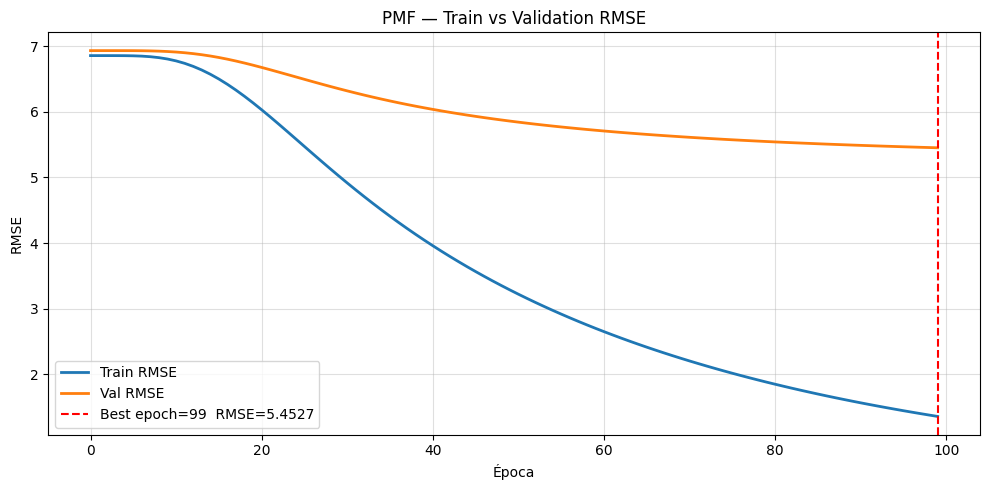

"\npredictions = pmf.predict_test(\n    x_test, user_map, item_map,\n    user_means, item_means, global_mean,\n    cold_start_unknown_user = 'global_mean',\n    cold_start_unknown_item = 'user_mean',\n    cold_start_both         = 'const_7'\n)\n"

In [12]:
user_means, item_means, global_mean = compute_stats(sparse_matrix)

pmf = PMF(
    n_factors  = 20,
    lambda_U   = 0.01,
    lambda_V   = 0.01,
    lr         = 0.001,   # Adam es mucho más estable con lr fijo
    n_epochs   = 100,
    batch_size = 2048,
    optimizer  = 'adam'   # <-- cambio clave
)

pmf.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=100
)

pmf.plot_loss()
'''
predictions = pmf.predict_test(
    x_test, user_map, item_map,
    user_means, item_means, global_mean,
    cold_start_unknown_user = 'global_mean',
    cold_start_unknown_item = 'user_mean',
    cold_start_both         = 'const_7'
)
'''

Training PMF: 100%|██████████| 10/10 [01:18<00:00,  7.85s/it]


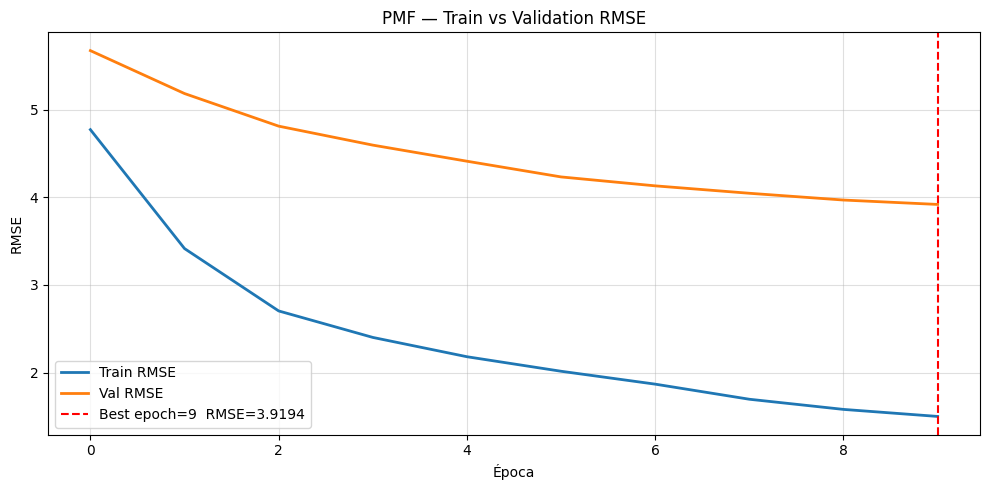

In [15]:
pmf2 = PMF(
    n_factors  = 10,
    lambda_U   = 0.01,
    lambda_V   = 0.01,
    lr         = 0.1,   # Adam es mucho más estable con lr fijo
    n_epochs   = 10,
    batch_size = 32,
    optimizer  = 'adam'   # <-- cambio clave
)

pmf2.fit(
    x_train, y_train, x_val, y_val,
    user_map, item_map,
    patience=100
)
pmf2.plot_loss()

